## Imports

In [120]:
import os
import cv2, random
import numpy as np
from glob import glob
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from glob import glob
from itertools import combinations

## Preprocessing (Morphology + Noise Removal)

In [121]:
def preprocess_image(img):
    # Ensure grayscale
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Mild Gaussian blur to reduce noise, preserve edges
    blurred = cv2.GaussianBlur(img, (3,3), 0)
    # Optional: histogram equalization to enhance contrast
    eq = cv2.equalizeHist(blurred)
    return eq

## Segmentation 

In [122]:
def segment_iris(img):
    # Pupil detection (small dark circle)
    pupil_circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                                     param1=50, param2=30, minRadius=20, maxRadius=60)
    # Iris detection (larger circle)
    iris_circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                                    param1=50, param2=30, minRadius=70, maxRadius=150)

    pupil = None
    iris = None
    if pupil_circles is not None:
        pupil = np.uint16(np.around(pupil_circles[0][0]))  # x, y, r
    if iris_circles is not None:
        # Pick the circle closest to pupil center
        if pupil is not None:
            iris_arr = np.uint16(np.around(iris_circles[0]))
            distances = [np.linalg.norm([c[0]-pupil[0], c[1]-pupil[1]]) for c in iris_arr]
            iris = iris_arr[np.argmin(distances)]
        else:
            iris = np.uint16(np.around(iris_circles[0][0]))
    return pupil, iris

## Normalization 

In [123]:
def normalize_iris(img, pupil, iris, radial_res=64, angular_res=512):
    cx_p, cy_p, r_p = pupil
    cx_i, cy_i, r_i = iris

    theta = np.linspace(0, 2*np.pi, angular_res)
    r = np.linspace(0, 1, radial_res)
    theta_grid, r_grid = np.meshgrid(theta, r)

    # Linear interpolation from pupil to iris
    x = cx_p + (r_p + r_grid * (r_i - r_p)) * np.cos(theta_grid)
    y = cy_p + (r_p + r_grid * (r_i - r_p)) * np.sin(theta_grid)

    # Clamp coordinates
    x = np.clip(x, 0, img.shape[1]-1)
    y = np.clip(y, 0, img.shape[0]-1)

    norm = cv2.remap(img.astype(np.float32),
                     x.astype(np.float32),
                     y.astype(np.float32),
                     interpolation=cv2.INTER_CUBIC)
    return norm


## Feature Extraction and encoding (Log-Gobor Filter)

In [124]:
def log_gabor_encode(norm_img):
    fft_rows = np.fft.fft(norm_img, axis=1)
    magnitude = np.abs(fft_rows)
    median_val = np.median(magnitude)
    template = (magnitude > median_val).astype(np.uint8)

    # Mask: ignore top/bottom 10%
    mask = np.ones_like(template, dtype=np.uint8)
    h = template.shape[0]
    mask[:h//10, :] = 0
    mask[-h//10:, :] = 0
    return template, mask

## Matching (Hamming Distace)

In [125]:
def hamming_distance(t1, t2, m1=None, m2=None):
    if m1 is None: m1 = np.ones_like(t1, dtype=np.uint8)
    if m2 is None: m2 = np.ones_like(t2, dtype=np.uint8)
    valid_mask = m1 & m2
    valid_bits = np.sum(valid_mask)
    if valid_bits == 0:
        return 1.0
    xor = np.logical_xor(t1, t2) & valid_mask
    return np.sum(xor) / valid_bits


## Evaluation 

In [126]:
def evaluate(dataset_path):
    subjects = sorted(os.listdir(dataset_path))
    genuine_scores = []
    impostor_scores = []

    # Precompute templates per subject
    subject_templates = {}
    for subject in subjects:
        images = glob(os.path.join(dataset_path, subject, "*.bmp"))
        templates = []

        for img_path in images:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            proc = preprocess_image(img)
            pupil, iris = segment_iris(proc)
            if pupil is None or iris is None: continue
            norm = normalize_iris(proc, pupil, iris)
            template, mask = log_gabor_encode(norm)
            templates.append((template, mask))

        if templates:
            subject_templates[subject] = templates

    # Genuine scores
    for subject, templates in subject_templates.items():
        for i, j in combinations(range(len(templates)), 2):
            t1, m1 = templates[i]
            t2, m2 = templates[j]
            score = hamming_distance(t1, t2, m1, m2)
            genuine_scores.append(score)

    # Impostor scores
    subject_list = list(subject_templates.keys())
    for i in range(len(subject_list)):
        for j in range(i+1, len(subject_list)):
            templates_i = subject_templates[subject_list[i]]
            templates_j = subject_templates[subject_list[j]]
            if not templates_i or not templates_j:
                continue
            t1, m1 = random.choice(templates_i)
            t2, m2 = random.choice(templates_j)
            score = hamming_distance(t1, t2, m1, m2)
            impostor_scores.append(score)

    return genuine_scores, impostor_scores

## Metric & Plots

In [127]:
def show_preprocessing(img, proc):
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Original Iris Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("After Preprocessing")
    plt.imshow(proc, cmap="gray")
    plt.axis("off")
    plt.show()

In [128]:
def show_segmentation(img, pupil, iris):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    if pupil is not None:
        cv2.circle(img_rgb, (pupil[0], pupil[1]), pupil[2], (0,255,0), 2)
    if iris is not None:
        cv2.circle(img_rgb, (iris[0], iris[1]), iris[2], (0,0,255), 2)

    plt.figure(figsize=(4,4))
    plt.title("Segmentation (Pupil + Iris)")
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [129]:
def show_normalization(norm):
    plt.figure(figsize=(6,3))
    plt.title("Normalized Iris (Rubber Sheet)")
    plt.imshow(norm, cmap="gray", aspect="auto")
    plt.axis("off")
    plt.show()

In [130]:
def show_encoded_features(template):
    plt.figure(figsize=(6,3))
    plt.title("Encoded Iris Features (Template)")
    plt.imshow(template, cmap="gray", aspect="auto")
    plt.axis("off")
    plt.show()

In [131]:
def plot_score_distributions(genuine, impostor):
    plt.figure(figsize=(8,5))
    plt.hist(genuine, bins=50, alpha=0.5, label="Genuine")
    plt.hist(impostor, bins=50, alpha=0.5, label="Impostor")
    plt.axvline(np.mean(genuine), color="blue", linestyle="--", label=f"Genuine Mean={np.mean(genuine):.3f}")
    plt.axvline(np.mean(impostor), color="red", linestyle="--", label=f"Impostor Mean={np.mean(impostor):.3f}")
    plt.xlabel("Hamming Distance")
    plt.ylabel("Frequency")
    plt.title("Score Distributions")
    plt.legend()
    plt.show()

In [132]:

def plot_roc_eer(genuine, impostor):
    y_true = [1]*len(genuine) + [0]*len(impostor)
    y_scores = genuine + impostor
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.3f}, EER≈{eer:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

    return eer, eer_threshold

In [133]:
def debug_pipeline(dataset_path):
    subjects = sorted(os.listdir(dataset_path))
    subject = random.choice(subjects)
    images = glob(os.path.join(dataset_path, subject, "*.bmp"))
    if not images:
        print("No images found")
        return
    img_path = random.choice(images)
    print(f"Debugging: {img_path}")

    img = cv2.imread(img_path)
    proc = preprocess_image(img)

    pupil, iris = segment_iris(proc)
    if pupil is None or iris is None:
        print("Segmentation failed")
        return

    norm = normalize_iris(proc, pupil, iris)
    template, mask = log_gabor_encode(norm)

    # Visualization
    img_rgb = cv2.cvtColor(proc, cv2.COLOR_GRAY2BGR)
    cv2.circle(img_rgb, (pupil[0], pupil[1]), pupil[2], (0,255,0), 2)
    cv2.circle(img_rgb, (iris[0], iris[1]), iris[2], (0,0,255), 2)

    plt.figure(figsize=(12,3))
    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Preprocessed")
    plt.imshow(proc, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Segmentation")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Normalized")
    plt.imshow(norm, cmap="gray", aspect="auto")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8,3))
    plt.title("Encoded Template")
    plt.imshow(template, cmap="gray", aspect="auto")
    plt.axis("off")
    plt.show()


In [134]:
def debug_scores(genuine, impostor):
    # Show distributions
    plot_score_distributions(genuine, impostor)

    # Show ROC + EER
    eer, thr = plot_roc_eer(genuine, impostor)
    print(f"EER={eer:.4f}, Threshold={thr:.4f}")

## Main

Debugging: IITD Database/103\02_L.bmp


C:\Users\User\AppData\Local\Temp\ipykernel_6188\1981557328.py:17: RuntimeWarning: overflow encountered in scalar subtract
  distances = [np.linalg.norm([c[0]-pupil[0], c[1]-pupil[1]]) for c in iris_arr]


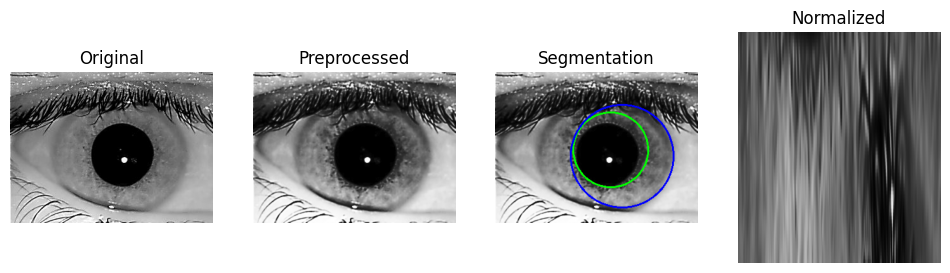

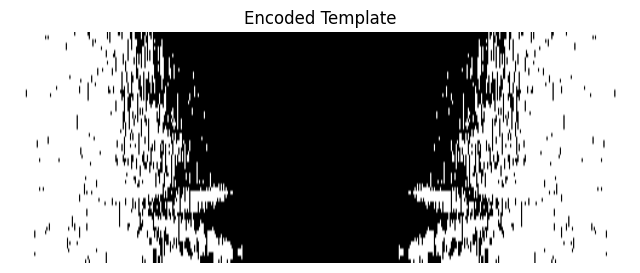

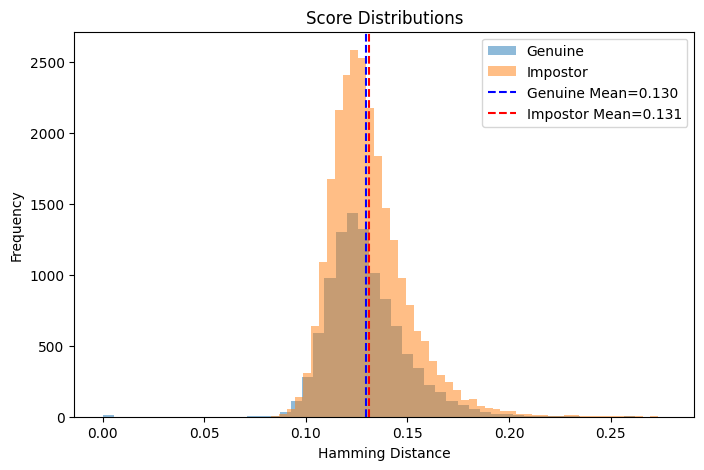

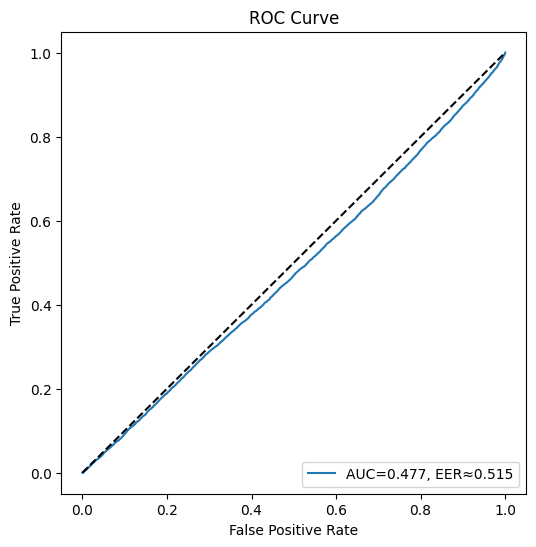

EER=0.5147, Threshold=0.1273


In [135]:
debug_pipeline("IITD Database/")
genuine, impostor = evaluate("IITD Database/")
plot_score_distributions(genuine, impostor)
eer, thr = plot_roc_eer(genuine, impostor)
print(f"EER={eer:.4f}, Threshold={thr:.4f}")